In [26]:
import numpy as np
from tensorflow.keras.datasets import mnist
from sklearn.decomposition import PCA

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train_reshaped = x_train.reshape(x_train.shape[0], -1)

pca = PCA()
X_1 = pca.fit_transform(x_train_reshaped)
pca.get_covariance()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [27]:
var_1=pca.explained_variance_ratio_
var_1

array([9.70466436e-02, 7.09592406e-02, 6.16908876e-02, 5.38941949e-02,
       4.86879702e-02, 4.31223132e-02, 3.27192995e-02, 2.88389545e-02,
       2.76202940e-02, 2.35700055e-02, 2.10918962e-02, 2.02299108e-02,
       1.71581820e-02, 1.69211143e-02, 1.57864128e-02, 1.48295261e-02,
       1.32456095e-02, 1.27689737e-02, 1.18726294e-02, 1.15268370e-02,
       1.06616621e-02, 1.00671337e-02, 9.53573327e-03, 9.12543746e-03,
       8.83404692e-03, 8.39319141e-03, 8.12578809e-03, 7.86366084e-03,
       7.44733102e-03, 6.90859128e-03, 6.58093773e-03, 6.48147870e-03,
       6.02615030e-03, 5.86582188e-03, 5.70021474e-03, 5.43627771e-03,
       5.05786416e-03, 4.87858604e-03, 4.81429342e-03, 4.72266326e-03,
       4.56746921e-03, 4.44836012e-03, 4.18501329e-03, 3.98215339e-03,
       3.84974607e-03, 3.75103387e-03, 3.62008852e-03, 3.51591277e-03,
       3.40058205e-03, 3.21874467e-03, 3.19017051e-03, 3.12804939e-03,
       2.95982668e-03, 2.88954600e-03, 2.84130398e-03, 2.71435811e-03,
      

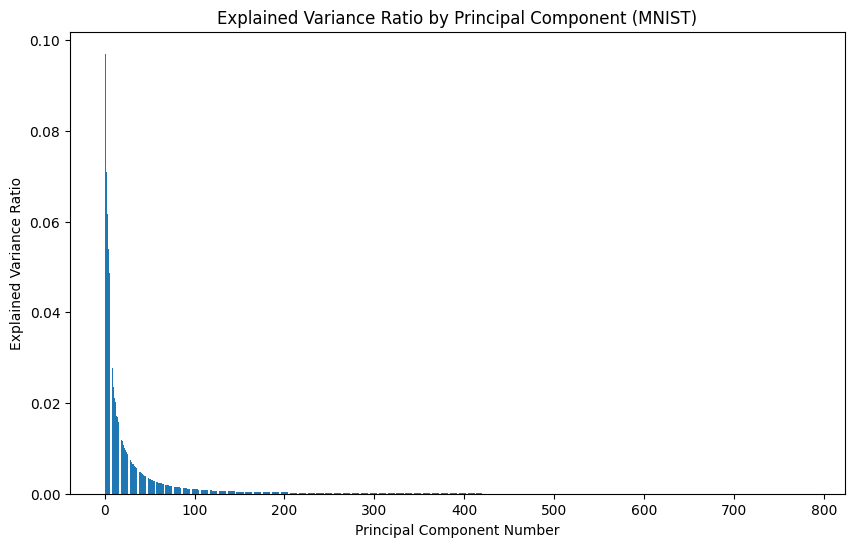

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(var_1) + 1), var_1)
plt.xlabel('Principal Component Number')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance Ratio by Principal Component (MNIST)')
plt.show()

In [29]:
print(f"Percentage sum of explained variance for the first two components: {np.round(np.sum(var_1[:2])*100, 2)}%")

Percentage sum of explained variance for the first two components: 16.8%


In [30]:
X_2_components = X_1[:, :2]
print(f"Shape of data projected onto the first two principal components: {X_2_components.shape}")
print(f"First 5 rows of the projected data:\n{X_2_components[:5]}")

Shape of data projected onto the first two principal components: (60000, 2)
First 5 rows of the projected data:
[[ 123.93258866  312.67426202]
 [1011.71837587  294.85703827]
 [ -51.84960805 -392.17315286]
 [-799.12703657  607.19721723]
 [-382.75494235 -730.54286723]]


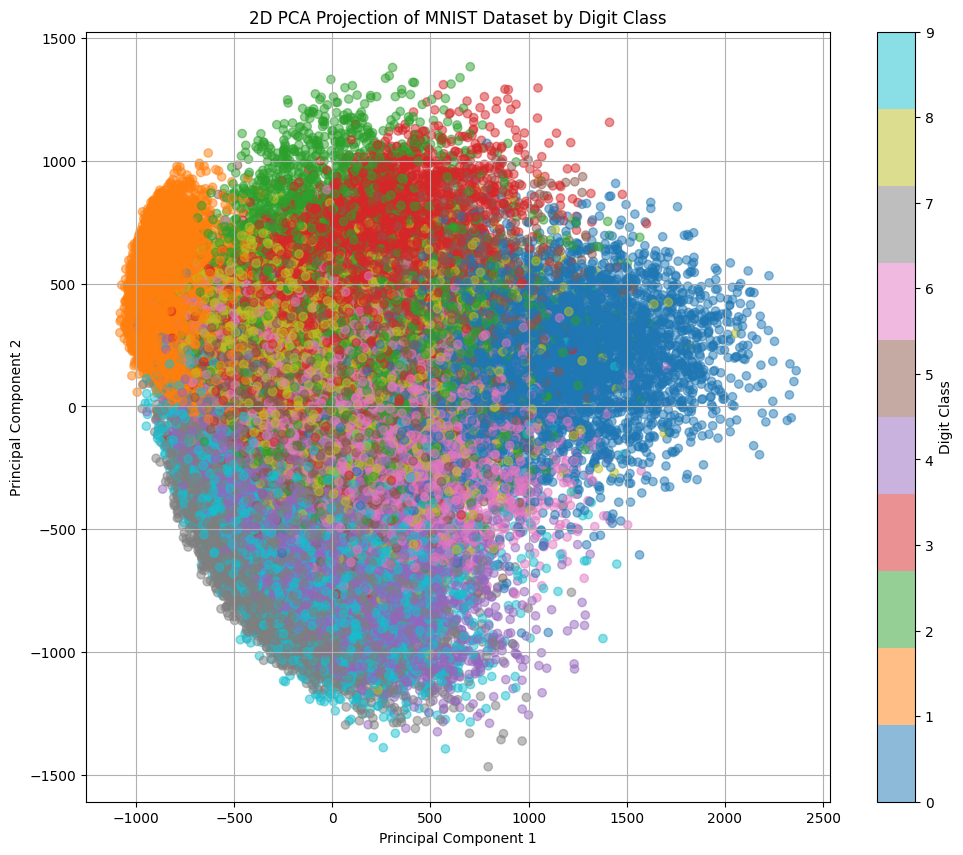

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
scatter = plt.scatter(X_2_components[:, 0], X_2_components[:, 1], c=y_train, cmap='tab10', alpha=0.5)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('2D PCA Projection of MNIST Dataset by Digit Class')
plt.colorbar(scatter, label='Digit Class')
plt.grid(True)
plt.show()

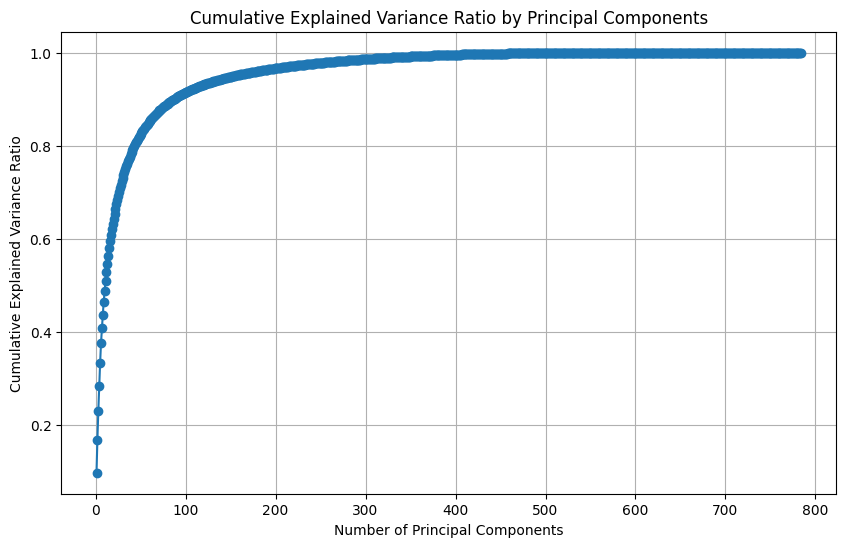

In [32]:
cumulative_variance = np.cumsum(var_1)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance Ratio by Principal Components')
plt.grid(True)
plt.show()

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits
import pandas as pd
digits=load_digits()

In [34]:
print(digits['data'].shape)
print(digits['target'].shape)

(1797, 64)
(1797,)


In [35]:
tsne=TSNE(n_components=2,random_state=42)

In [36]:
x_transformed=tsne.fit_transform(digits['data'])

In [38]:
tsne_df=pd.DataFrame(np.column_stack((x_transformed,digits['target'])),columns=['x','y','Targets'])
tsne_df.loc[:, 'Targets'] = tsne_df.Targets.astype(int)

In [40]:
tsne_df.head(10)

,x,y,Targets
0,-3.024210,-53.885437,0.0
1,10.376657,11.264841,1.0
2,-13.521493,18.822712,2.0
3,-35.524765,-6.349295,3.0
4,40.953392,7.328811,4.0
5,-27.095041,-15.059107,5.0
6,34.530472,-14.780560,6.0
7,2.225859,42.040230,7.0
8,-14.532291,5.938167,8.0
9,-20.070793,-15.172290,9.0


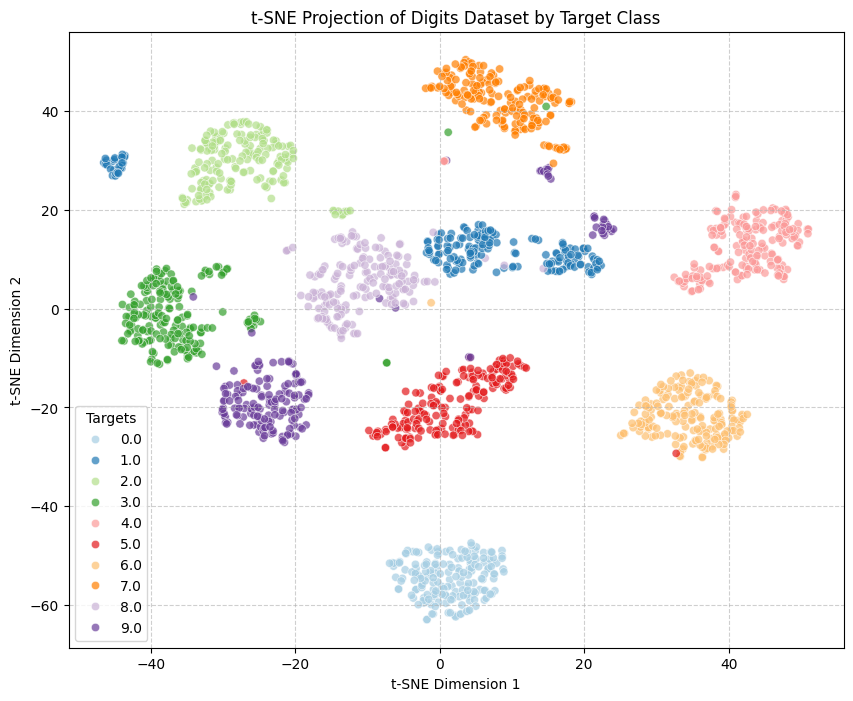

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='x',
    y='y',
    hue='Targets',
    palette=sns.color_palette('Paired', 10),
    data=tsne_df,
    legend='full',
    alpha=0.7
)
plt.title('t-SNE Projection of Digits Dataset by Target Class')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()